In [4]:
pwd

'/home/sangonvi/Cefet/repositories/rionowcastdf'

In [5]:
# =============================================================================
# Notebook 06
# Spatial Mean Climatology
#
# Objective
# ---------
# Compute and visualize the spatial climatology of rainfall over the
# entire historical radar archive (2011–2024).
#
# Products:
#
# 1) Mean reflectivity map
# 2) Rain occurrence probability map
# 3) Standard deviation map
# 4) Maximum observed reflectivity
#
# =============================================================================

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

RADAR_STATISTICS_DIR= Path("datasets/radar_statistics")


FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)

stats = Path(RADAR_STATISTICS_DIR)

In [6]:
mean_grid = np.load(stats / "mean_grid.npy")

std_grid = np.load(stats / "std_grid.npy")

max_grid = np.load(stats / "max_grid.npy")

rain_probability = np.load(
    stats / "rain_probability.npy"
)

rain_occurrence = np.load(
    stats / "rain_occurrence.npy"
)

accumulated = np.load(
    stats / "accumulated_rain.npy"
)

In [7]:
print("Mean:", mean_grid.shape)

print("Std :", std_grid.shape)

print("Max :", max_grid.shape)

print("Probability:", rain_probability.shape)

Mean: (70, 84)
Std : (70, 84)
Max : (70, 84)
Probability: (70, 84)


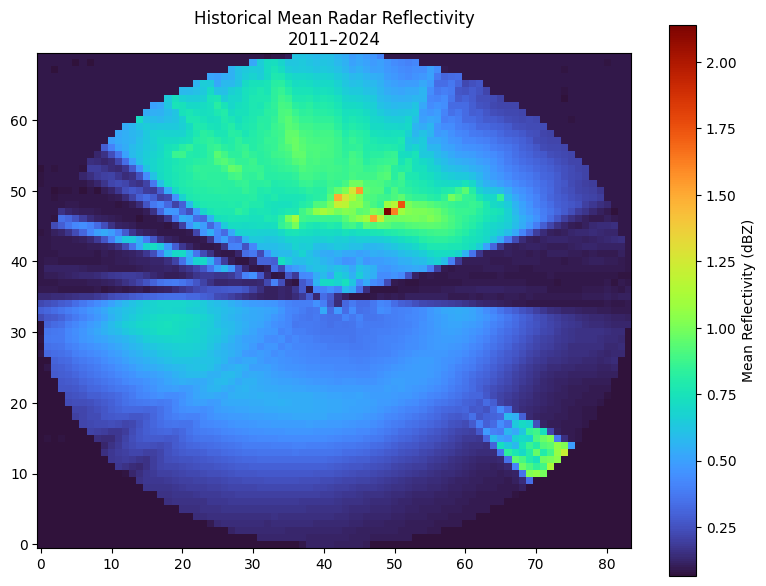

In [8]:
plt.figure(figsize=(8,6))

im = plt.imshow(
    mean_grid,
    origin="lower",
    cmap="turbo"
)

plt.colorbar(
    im,
    label="Mean Reflectivity (dBZ)"
)

plt.title(
    "Historical Mean Radar Reflectivity\n2011–2024"
)

plt.tight_layout()

plt.savefig(
    FIGURES/"figure06_mean_field.png",
    dpi=300
)

plt.show()

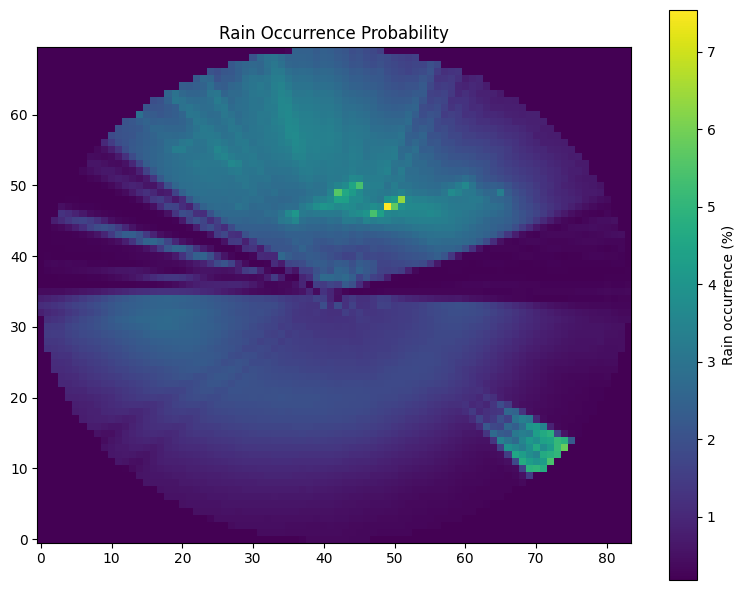

In [9]:
plt.figure(figsize=(8,6))

im = plt.imshow(
    rain_probability*100,
    origin="lower",
    cmap="viridis"
)

plt.colorbar(
    im,
    label="Rain occurrence (%)"
)

plt.title(
    "Rain Occurrence Probability"
)

plt.tight_layout()

plt.savefig(
    FIGURES/"figure06_probability.png",
    dpi=300
)

plt.show()

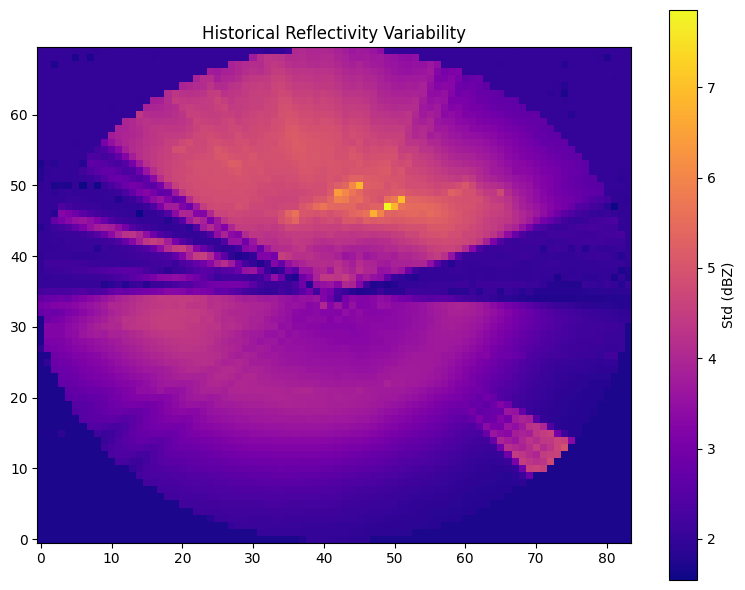

In [10]:
plt.figure(figsize=(8,6))

im = plt.imshow(
    std_grid,
    origin="lower",
    cmap="plasma"
)

plt.colorbar(
    im,
    label="Std (dBZ)"
)

plt.title(
    "Historical Reflectivity Variability"
)

plt.tight_layout()

plt.savefig(
    FIGURES/"figure06_std.png",
    dpi=300
)

plt.show()

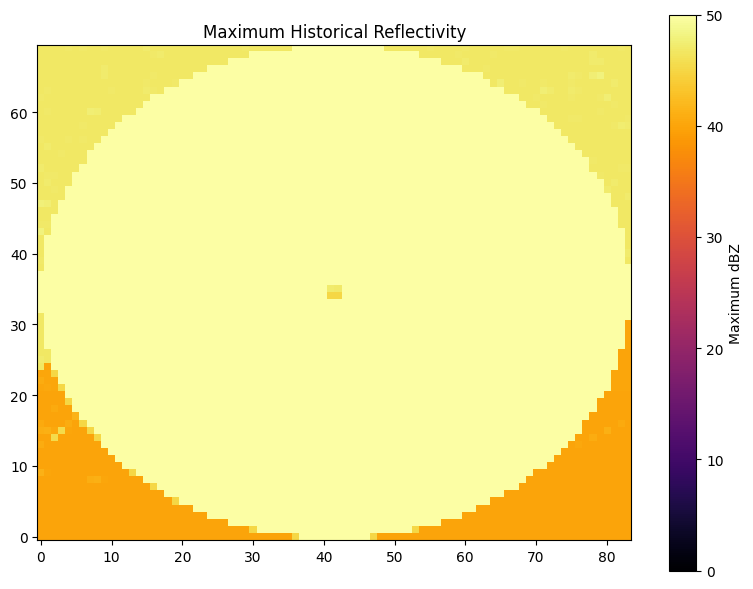

In [11]:
plt.figure(figsize=(8,6))

im = plt.imshow(
    max_grid,
    origin="lower",
    cmap="inferno",
    vmin=0,
    vmax=50
)

plt.colorbar(
    im,
    label="Maximum dBZ"
)

plt.title(
    "Maximum Historical Reflectivity"
)

plt.tight_layout()

plt.savefig(
    FIGURES/"figure06_maximum.png",
    dpi=300
)

plt.show()

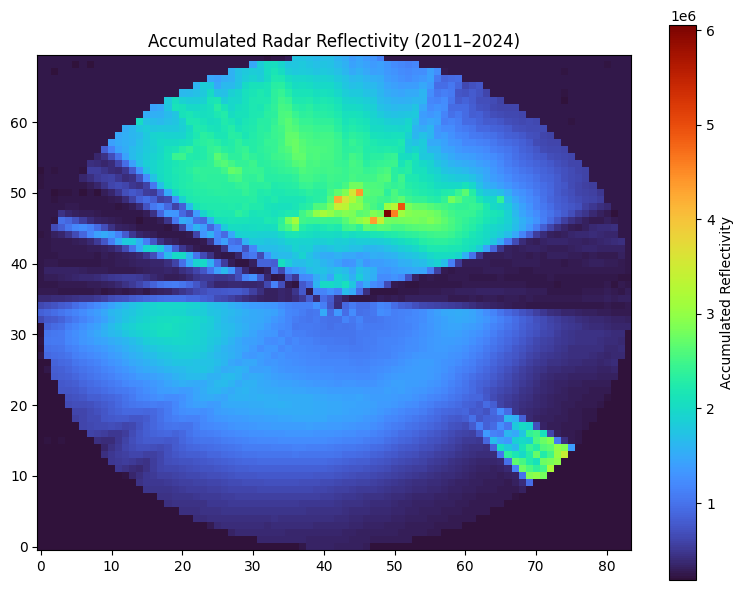

In [12]:
plt.figure(figsize=(8,6))

im = plt.imshow(
    accumulated,
    origin="lower",
    cmap="turbo"
)

plt.colorbar(
    im,
    label="Accumulated Reflectivity"
)

plt.title(
    "Accumulated Radar Reflectivity (2011–2024)"
)

plt.tight_layout()

plt.savefig(
    FIGURES/"figure06_accumulated.png",
    dpi=300
)

plt.show()

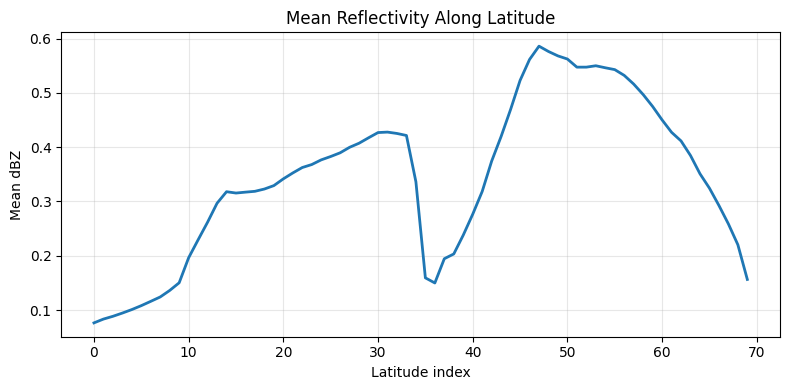

In [14]:
lat_profile = mean_grid.mean(axis=1)

lon_profile = mean_grid.mean(axis=0)

plt.figure(figsize=(8,4))

plt.plot(
    lat_profile,
    linewidth=2
)

plt.grid(alpha=0.3)

plt.title(
    "Mean Reflectivity Along Latitude"
)

plt.xlabel("Latitude index")

plt.ylabel("Mean dBZ")

plt.tight_layout()

plt.savefig(
    FIGURES/"figure06_lat_profile.png",
    dpi=300
)

plt.show()

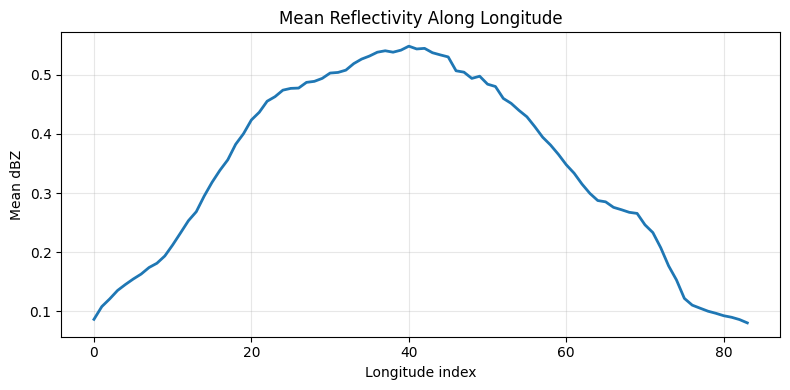

In [15]:
plt.figure(figsize=(8,4))

plt.plot(
    lon_profile,
    linewidth=2
)

plt.grid(alpha=0.3)

plt.title(
    "Mean Reflectivity Along Longitude"
)

plt.xlabel("Longitude index")

plt.ylabel("Mean dBZ")

plt.tight_layout()

plt.savefig(
    FIGURES/"figure06_lon_profile.png",
    dpi=300
)

plt.show()

In [16]:
print("="*60)

print("Spatial Climatology Summary")

print("="*60)

print(f"Mean reflectivity      : {mean_grid.mean():.3f}")

print(f"Maximum mean           : {mean_grid.max():.3f}")

print(f"Maximum observed       : {max_grid.max():.3f}")

print(f"Average std            : {std_grid.mean():.3f}")

print(f"Maximum probability    : {rain_probability.max()*100:.2f}%")

print(f"Average probability    : {rain_probability.mean()*100:.2f}%")

print("="*60)

Spatial Climatology Summary
Mean reflectivity      : 0.343
Maximum mean           : 2.140
Maximum observed       : 50.000
Average std            : 2.996
Maximum probability    : 7.54%
Average probability    : 1.25%
